## **Loan Classification**
***Business-Driven Data Analysis***

## **Basic Setup**

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
from google.colab import files
uploaded=files.upload()

Saving loan_data.csv to loan_data (1).csv


In [55]:
filename=list(uploaded.keys())[0]
if filename.endswith('csv'):
  df=pd.read_csv(filename)
else:
  df=pd.read_excel(filename)

##  **Data Overview and Quality Check**

In [56]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [58]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [59]:
df = df.drop(columns=['person_emp_exp', 'cb_person_cred_hist_length'])
df.head()

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,RENT,35000.0,PERSONAL,16.02,0.49,561,No,1
1,21.0,female,High School,12282.0,OWN,1000.0,EDUCATION,11.14,0.08,504,Yes,0
2,25.0,female,High School,12438.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,635,No,1
3,23.0,female,Bachelor,79753.0,RENT,35000.0,MEDICAL,15.23,0.44,675,No,1
4,24.0,male,Master,66135.0,RENT,35000.0,MEDICAL,14.27,0.53,586,No,1


In [60]:
df['loan_percent_income'] = df['loan_percent_income'].fillna(df['loan_percent_income'].mode()[0])
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mode()[0])
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].mean())
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].fillna(df['previous_loan_defaults_on_file'].mode()[0])
df['loan_status'] = df['loan_status'].fillna(df['loan_status'].mode()[0])

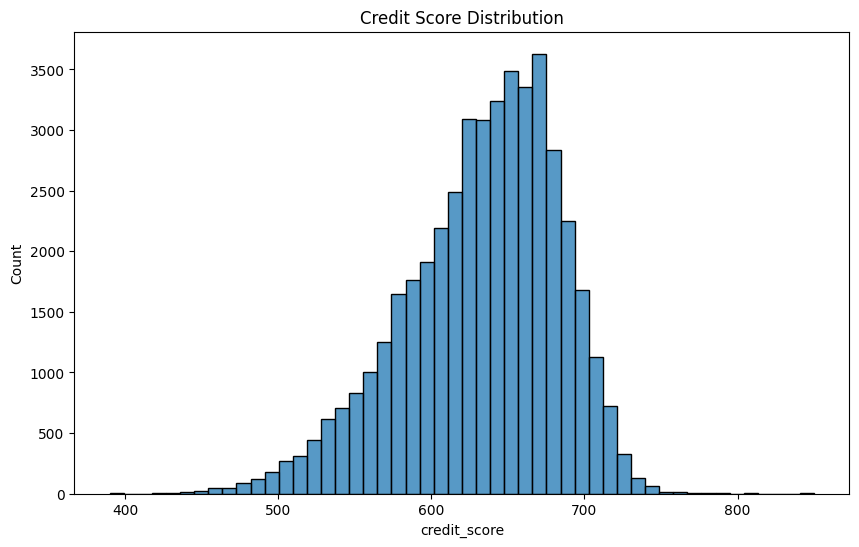

In [61]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='credit_score', bins=50)
plt.title('Credit Score Distribution')
plt.show()

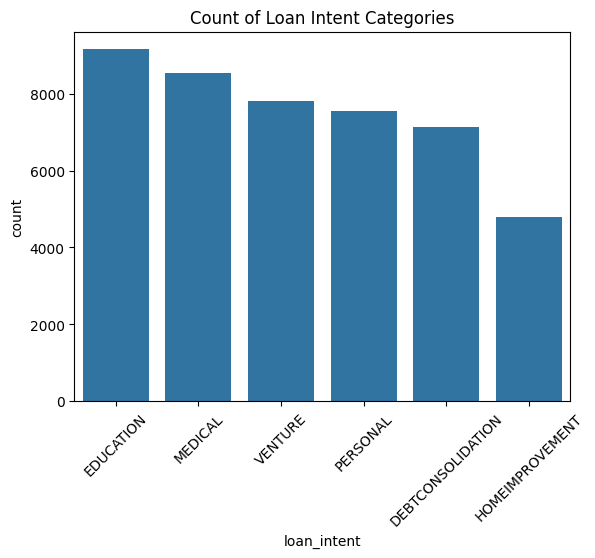

In [62]:
intent_count=df['loan_intent'].value_counts().reset_index()
intent_count.columns = ['loan_intent', 'count']
sns.barplot(data=intent_count, x='loan_intent', y='count')
plt.xticks(rotation=45)
plt.title('Count of Loan Intent Categories')
plt.show()

Columns 'person_emp_exp', 'cb_person_cred_hist_length' were removed from the dataset based on their irrelvance for this project. Furthermore, missing values were handled to ensure model compatibility and to avoid dropping observations (mode for categorical features, mean for continuous ones).
### Data Visualization

To better understand the dataset, basic visualizations were created.

A histogram of `credit_score` was used to examine the distribution of credit scores across applicants. This helps identify the range, central tendency, and any potential skewness in the data.

A bar plot of `loan_intent` was used to analyze the frequency of different loan purposes. This provides insight into which types of loans are most common in the dataset.

These visualizations help in understanding the structure of the data and can inform modeling decisions.

## **Modelling**

In [63]:
#split Features & Target

x = df.drop('loan_status', axis=1)
y = df['loan_status']

In [64]:
# split training and testing

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [65]:
# encoding and scaling

from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

#create instance
encoder = OrdinalEncoder()
scaler = MinMaxScaler()

# fit transform on training
numeric = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income',	'credit_score']
categories = ['person_gender',	'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


x_train[numeric] = scaler.fit_transform(x_train[numeric])
x_train[categories] = encoder.fit_transform(x_train[categories])

x_test[numeric] = scaler.transform(x_test[numeric])
x_test[categories] = encoder.transform(x_test[categories])

# fit designs the rules that this scaler and encoder will follow
# test follows the same rules as training

In [66]:
# Applying SMOTE

from collections import Counter
from imblearn.over_sampling import SMOTE

In [67]:
print('Before SMOTE:', Counter(y_train))

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print('After SMOTE:', Counter(y_train_smote))

Before SMOTE: Counter({0: 24507, 1: 6993})
After SMOTE: Counter({0: 24507, 1: 24507})


In [68]:
x_train.head()

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
30159,0.145161,1.0,0.0,0.004668,3.0,0.152174,3.0,0.383402,0.225806,0.558696,1.0
6777,0.032258,0.0,0.0,0.002788,3.0,0.188406,0.0,0.356653,0.403226,0.563043,0.0
36563,0.064516,0.0,0.0,0.007747,0.0,0.188406,1.0,0.743484,0.177419,0.513043,1.0
11784,0.048387,1.0,0.0,0.011660,0.0,0.020290,4.0,0.331276,0.016129,0.591304,0.0
10370,0.016129,1.0,4.0,0.002996,3.0,0.275362,0.0,0.383402,0.548387,0.528261,0.0


## Modelling

# Feature and Target Split
The dataset was divided into features (`X`) and target (`y`), where `loan_status` represents the outcome variable to be predicted. This separation is necessary to train the model to learn the relationship between input variables and the target.

# Train-Test Split
The data was split into training (70%) and testing (30%) sets using `train_test_split`. This allows the model to be trained on one portion of the data and evaluated on unseen data, ensuring a more reliable assessment of performance.

# Encoding and Scaling
Since the dataset contains both numerical and categorical variables, preprocessing was applied:

- **Numerical features** were scaled using `MinMaxScaler` to bring all values into a comparable range. This helps models perform better, especially those sensitive to feature magnitude.
- **Categorical features** were transformed using `OrdinalEncoder` to convert them into numerical format required by machine learning algorithms.

The transformations were fitted only on the training data and then applied to the test data to avoid data leakage.

# Handling Class Imbalance (SMOTE)
The target variable (`loan_status`) was imbalanced, meaning one class (approved/declined) appeared more frequently than the other. To address this, **SMOTE (Synthetic Minority Oversampling Technique)** was applied to the training data.

SMOTE works by generating synthetic examples of the minority class rather than simply duplicating existing ones. This helps the model learn more balanced patterns and improves its ability to correctly classify the minority class.

Importantly, SMOTE was applied **only to the training data**, ensuring that the test set remains a true representation of unseen data.

## **Model Selection**

In [69]:
from sklearn.linear_model import LogisticRegression
# logistic regression works well with binary target

from sklearn.metrics import accuracy_score, confusion_matrix

model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)


0.8900740740740741

In [70]:
confusion_matrix(y_pred, y_test)


array([[9802,  793],
       [ 691, 2214]])

In [71]:
model = LogisticRegression()
model.fit(x_train_smote, y_train_smote)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.8534074074074074

In [72]:
accuracy_lr = accuracy_score(y_test, y_pred)
confusion_matrix(y_pred, y_test)

array([[8779,  265],
       [1714, 2742]])

In [73]:
df['loan_status'].value_counts() #my target is imbalanced we need to treat this before modeling

,count
loan_status,
0,35000
1,10000


In [74]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.8956296296296297

In [75]:
confusion_matrix(y_pred, y_test)

array([[9755,  671],
       [ 738, 2336]])

In [76]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train_smote, y_train_smote)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.8817037037037037

In [77]:
accuracy_dt = accuracy_score(y_test, y_pred)
confusion_matrix(y_pred, y_test)

array([[9489,  593],
       [1004, 2414]])

In [78]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.9205925925925926

In [79]:
confusion_matrix(y_pred, y_test)

array([[10144,   723],
       [  349,  2284]])

In [80]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_train_smote, y_train_smote)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.8917037037037037

In [81]:
accuracy_gb = accuracy_score(y_test, y_pred)
confusion_matrix(y_pred, y_test)

array([[9392,  361],
       [1101, 2646]])

In [82]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.9317777777777778

In [83]:
confusion_matrix(y_pred, y_test)

array([[10151,   579],
       [  342,  2428]])

In [84]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train_smote, y_train_smote)
y_pred = model.predict(x_test)
accuracy_score(y_pred, y_test)

0.9244444444444444

In [85]:
accuracy_xgb = accuracy_score(y_test, y_pred)
confusion_matrix(y_pred, y_test)

array([[9983,  510],
       [ 510, 2497]])

In [96]:
results = []

# Logistic Regression
results.append({
    'Model after SMOTE': 'Logistic Regression',
    'Accuracy': accuracy_lr,
})

# Decision Tree
results.append({
    'Model after SMOTE': 'Decision Tree',
    'Accuracy': accuracy_dt,
})

# Gradient Boosting
results.append({
    'Model after SMOTE': 'Gradient Boosting',
    'Accuracy': accuracy_gb,
})

# XGBoost
results.append({
    'Model after SMOTE': 'XGBoost',
    'Accuracy': accuracy_xgb,
})

results_df = pd.DataFrame(results)
results_df

,Model after SMOTE,Accuracy
0,Logistic Regression,0.853407
1,Decision Tree,0.881704
2,Gradient Boosting,0.891704
3,XGBoost,0.924444


# Model Selection

Multiple classification models were evaluated, including Logistic Regression, Decision Tree, Gradient Boosting, and XGBoost. Each model was trained both on the original dataset and on the SMOTE-balanced dataset to assess the impact of handling class imbalance.

Logistic Regression was used as a baseline model due to its simplicity and interpretability. However, it assumes a linear relationship between features and the target, which may limit performance on more complex patterns.

Tree-based models such as Decision Tree and Gradient Boosting were included as they can capture non-linear relationships and interactions between features. These models are generally more flexible and better suited for structured/tabular data.

XGBoost was also evaluated as an advanced boosting method known for strong performance in classification tasks, particularly on tabular datasets.

The final model (XGBoost) was selected based on its performance on the test set, considering both accuracy and the confusion matrix. Special attention was given to performance on the minority class due to the imbalanced nature of the problem.

## **Testing the Model**

In [87]:
x.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'credit_score',
       'previous_loan_defaults_on_file'],
      dtype='object')

In [88]:
x.dtypes

,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64
credit_score,int64


In [91]:
person_age = 28.0
person_gender = 'male'
person_education = 'Bachelor'
person_income = 60000.0
person_home_ownership = 'MORTGAGE'
loan_amnt = 15000.0
loan_intent = 'DEBTCONSOLIDATION'
loan_int_rate = 12.5
loan_percent_income = 0.25
credit_score = 700
previous_loan_defaults_on_file = 'No'

test = {'person_age':[person_age], 'person_gender':[person_gender], 'person_education':[person_education], 'person_income':[person_income], 'person_home_ownership':[person_home_ownership], 'loan_amnt':[loan_amnt], 'loan_intent':[loan_intent], 'loan_int_rate':[loan_int_rate], 'loan_percent_income':[loan_percent_income], 'credit_score':[credit_score], 'previous_loan_defaults_on_file':[previous_loan_defaults_on_file]}
test

{'person_age': [28.0],
 'person_gender': ['male'],
 'person_education': ['Bachelor'],
 'person_income': [60000.0],
 'person_home_ownership': ['MORTGAGE'],
 'loan_amnt': [15000.0],
 'loan_intent': ['DEBTCONSOLIDATION'],
 'loan_int_rate': [12.5],
 'loan_percent_income': [0.25],
 'credit_score': [700],
 'previous_loan_defaults_on_file': ['No']}

In [92]:
test = pd.DataFrame(test)
test

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,28.0,male,Bachelor,60000.0,MORTGAGE,15000.0,DEBTCONSOLIDATION,12.5,0.25,700,No


In [93]:
test[numeric] = scaler.transform(test[numeric])
test[categories] = encoder.transform(test[categories])
test

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,0.064516,1.0,1.0,0.007229,0.0,0.42029,0.0,0.485597,0.403226,0.673913,0.0


In [94]:
prediction = model.predict(test)[0]
print('approved' if prediction == 1 else 'declined')

declined


# Prediction on Test Data

A new user input is collected and converted into a DataFrame. The same preprocessing steps (scaling and encoding) are applied to ensure consistency with the training data.

The trained model then predicts whether the loan is approved or declined based on the input values.

# **Prediction on New Output**

In [95]:
try:
    person_age = float(input('person_age: '))
    person_gender = input('person_gender (female/male): ')
    person_education = input('person_education (Master/High School/Bachelor/Associate/Doctorate): ')
    person_income = float(input('person_income: '))
    person_home_ownership = input('person_home_ownership (RENT/OWN/MORTGAGE/OTHER): ')
    loan_amnt = float(input('loan_amnt: '))
    loan_intent = input('loan_intent (PERSONAL/EDUCATION/MEDICAL/VENTURE/HOMEIMPROVEMENT/DEBTCONSOLIDATION): ')
    loan_int_rate = float(input('loan_int_rate: '))
    loan_percent_income = float(input('loan_percent_income: '))
    credit_score = int(input('credit_score: '))
    previous_loan_defaults_on_file = input('previous_loan_defaults_on_file (No/Yes): ')

    new_data = pd.DataFrame({
        'person_age': [person_age],
        'person_gender': [person_gender],
        'person_education': [person_education],
        'person_income': [person_income],
        'person_home_ownership': [person_home_ownership],
        'loan_amnt': [loan_amnt],
        'loan_intent': [loan_intent],
        'loan_int_rate': [loan_int_rate],
        'loan_percent_income': [loan_percent_income],
        'credit_score': [credit_score],
        'previous_loan_defaults_on_file': [previous_loan_defaults_on_file]
    })

    new_data[numeric] = scaler.transform(new_data[numeric])
    new_data[categories] = encoder.transform(new_data[categories])

    prediction = model.predict(new_data)[0]
    print('approved' if prediction == 1 else 'declined')

except Exception as e:
    print('Error:', e)

KeyboardInterrupt: Interrupted by user

# Prediction on New Data

To simulate real-world usage, a new set of input values was manually provided to represent a loan applicant.

The input data was converted into a single-row DataFrame and processed using the same transformations applied during training:
- Numerical features were scaled using the fitted scaler
- Categorical features were encoded using the fitted encoder

This ensures consistency between training and prediction.

The processed data was then passed to the trained model, which outputs a prediction indicating whether the loan is likely to be approved or declined.

The result is finally displayed